<a href="https://colab.research.google.com/github/shravyaamarnath/ml-churn-prediction/blob/main/Apr_waze_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waze Churn Prediction

**Problem:** Predict which Waze users are likely to churn (uninstall the app) based on in-app behavior metrics.

**Why this matters (PM framing):** Acquiring a new user costs significantly more than retaining one. Identifying at-risk users early lets the product team trigger targeted retention interventions — push notifications, feature nudges, or re-engagement campaigns — before the user disengages entirely.

**Dataset:** [Waze Project — InaRailean/Waze-Project](https://github.com/InaRailean/Waze-Project)  
**Target variable:** `label` — `retained` vs `churned`  
**Features:** 11 behavioral + 1 device categorical

---
**Workflow:**
1. Data loading & inspection
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Preprocessing
5. Modeling: Logistic Regression → Random Forest → XGBoost
6. Evaluation & comparison
7. Feature importance & business interpretation

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, f1_score
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load directly from GitHub raw URL
URL = 'https://raw.githubusercontent.com/InaRailean/Waze-Project/main/waze_dataset.csv'
df = pd.read_csv(URL)
print(f'Shape: {df.shape}')
df.head()

Shape: (14999, 13)


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


## 2. Data Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [ ]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nMissing % in label: {df["label"].isnull().mean()*100:.2f}%')

Missing values:
ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

Missing % in label: 4.67%


In [ ]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


label
retained    11763
churned      2536
Name: count, dtype: int64

Churn rate: 17.7%


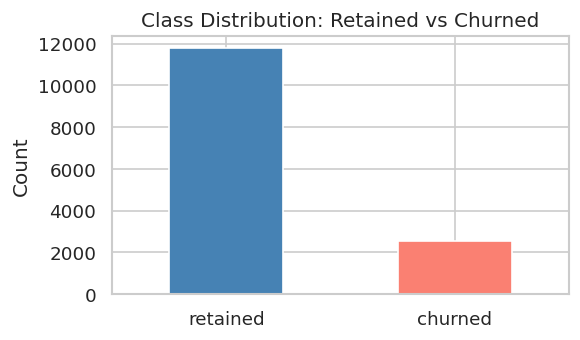

In [ ]:
# Class distribution
label_counts = df['label'].value_counts()
print(label_counts)
print(f'\nChurn rate: {label_counts["churned"] / label_counts.sum() * 100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 3))
label_counts.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_title('Class Distribution: Retained vs Churned')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis

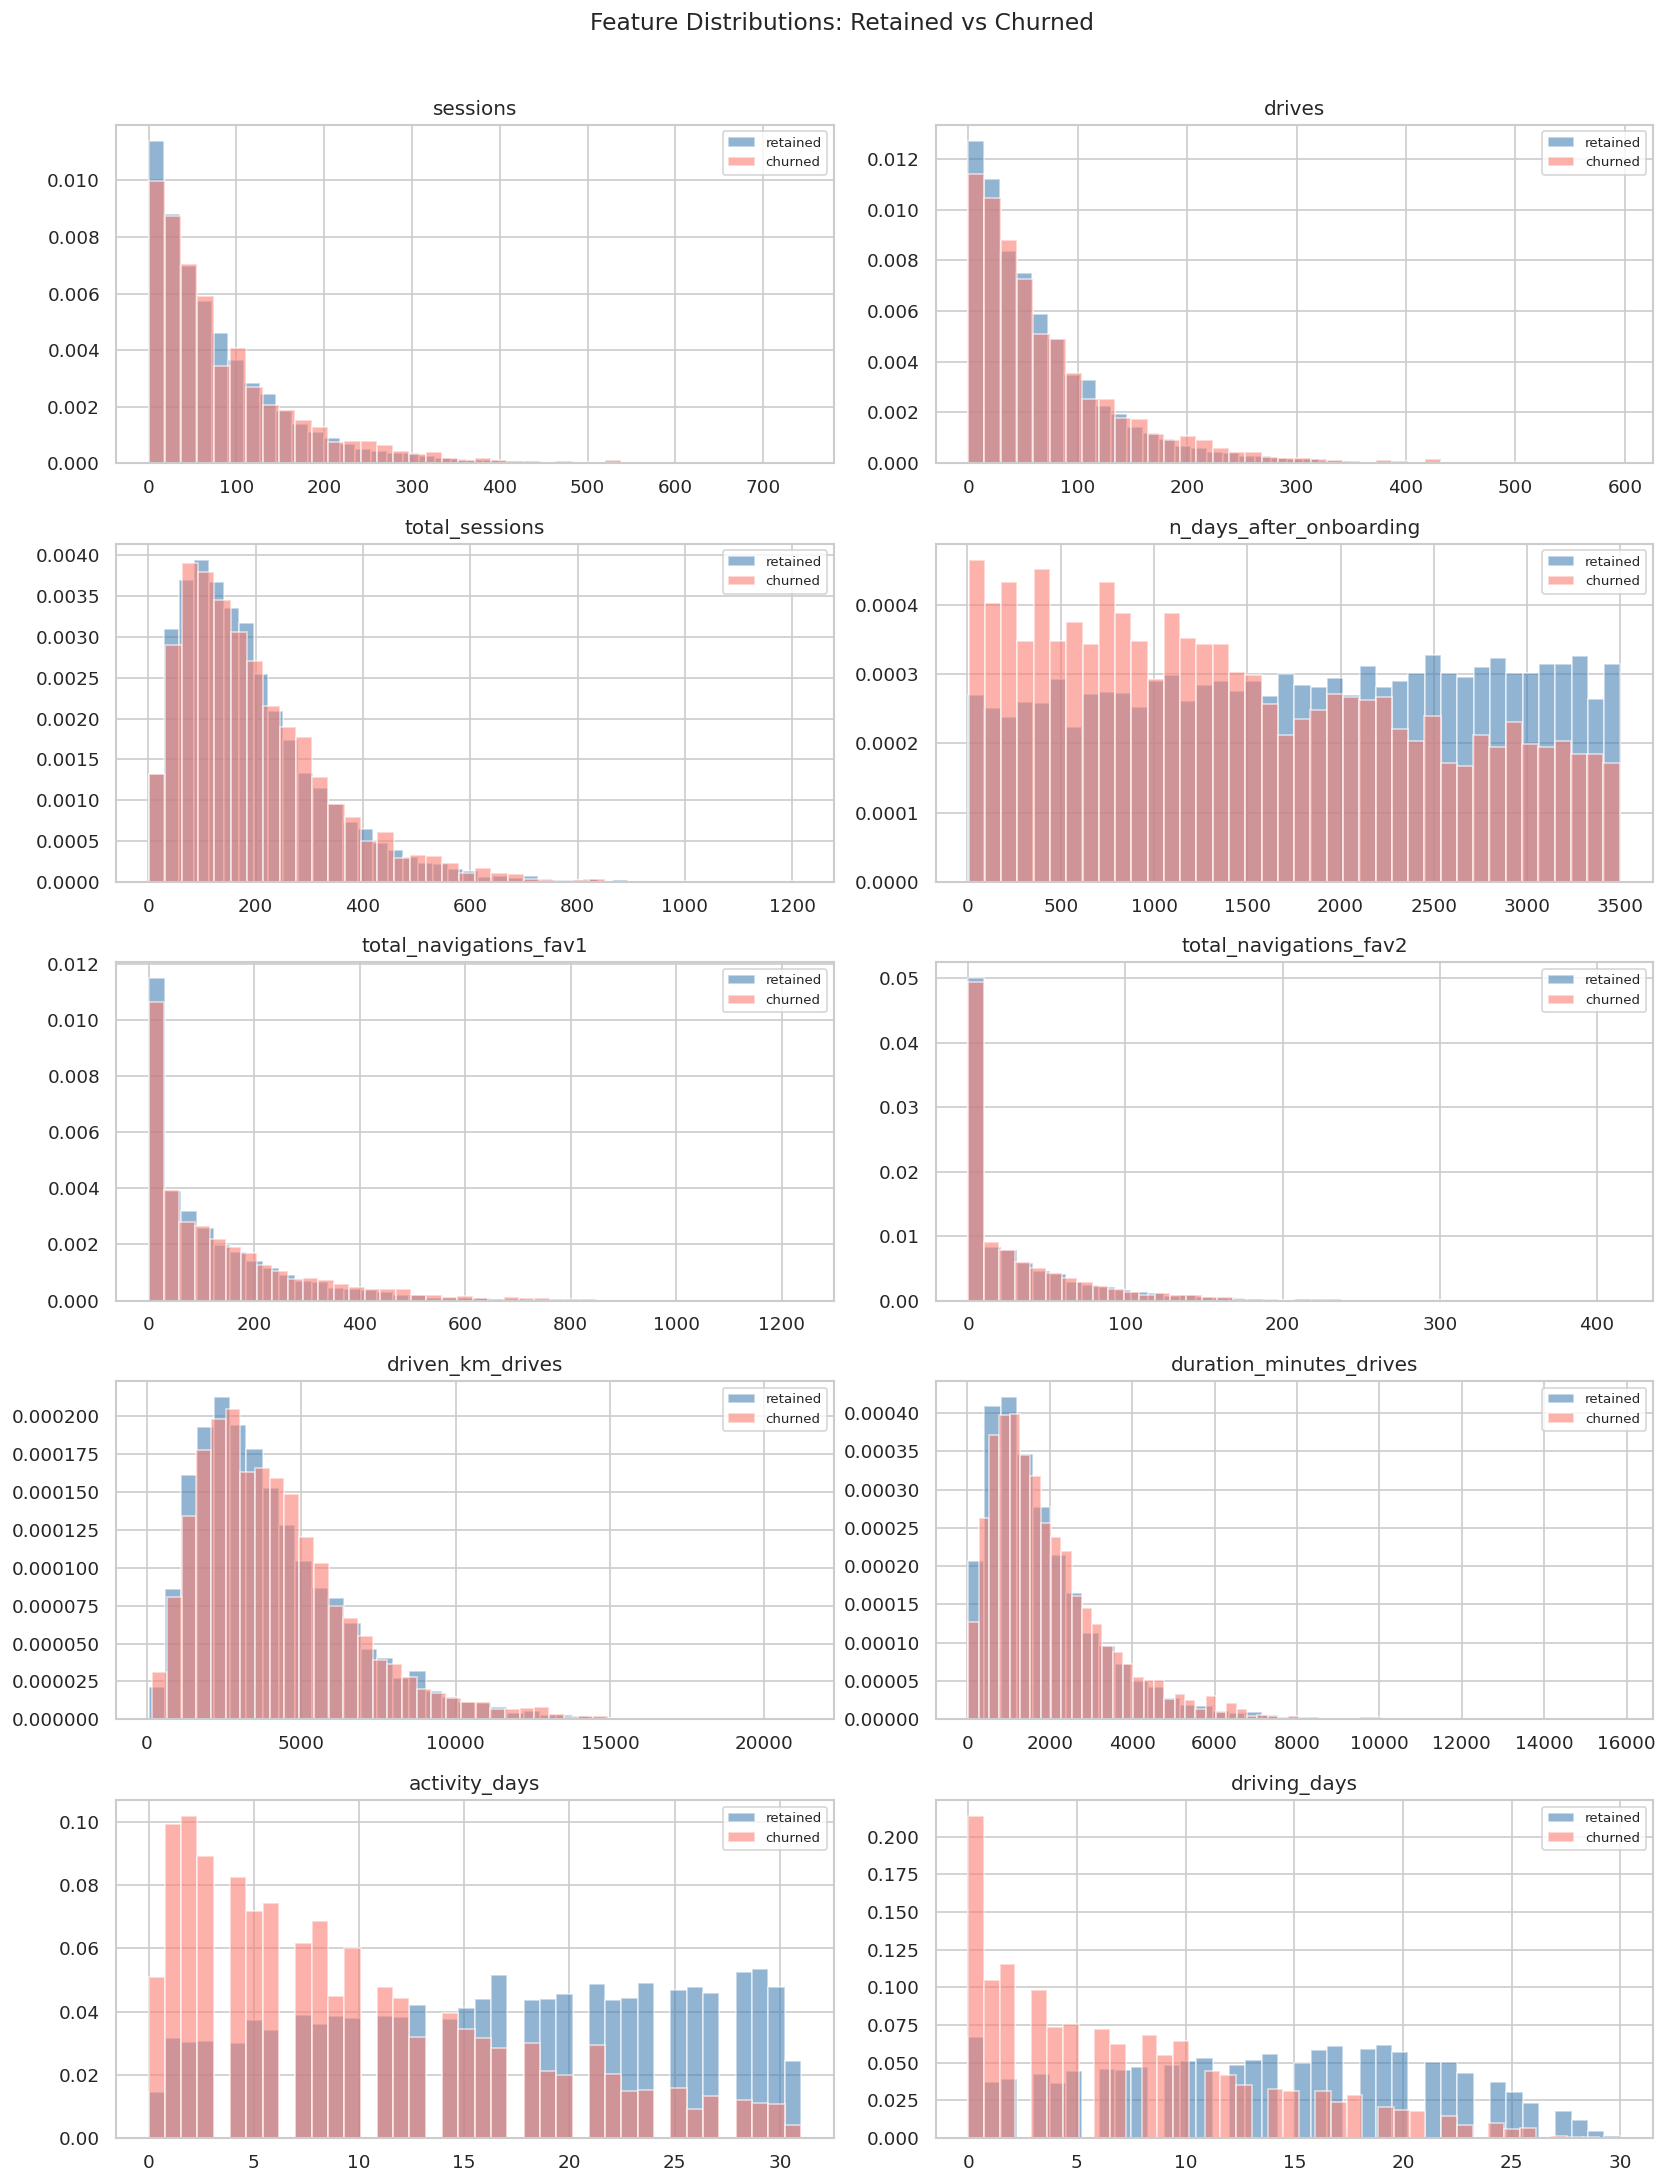

In [ ]:
# Numeric feature distributions by churn label
numeric_cols = [
    'sessions', 'drives', 'total_sessions', 'n_days_after_onboarding',
    'total_navigations_fav1', 'total_navigations_fav2',
    'driven_km_drives', 'duration_minutes_drives',
    'activity_days', 'driving_days'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
for ax, col in zip(axes.flatten(), numeric_cols):
    for label, color in [('retained', 'steelblue'), ('churned', 'salmon')]:
        df[df['label'] == label][col].dropna().hist(
            bins=40, ax=ax, alpha=0.6, color=color, label=label, density=True
        )
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions: Retained vs Churned', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

label    churned  retained
device                    
Android     17.6      82.4
iPhone      17.8      82.2


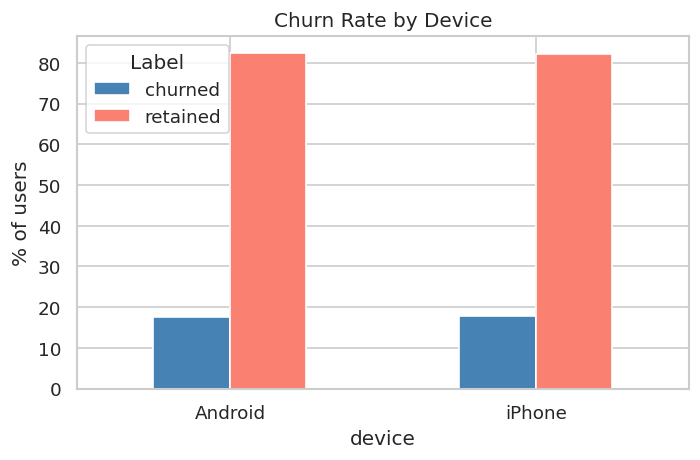

In [ ]:
# Device breakdown by churn
device_churn = df.groupby(['device', 'label']).size().unstack(fill_value=0)
device_churn_pct = device_churn.div(device_churn.sum(axis=1), axis=0) * 100
print(device_churn_pct.round(1))

device_churn_pct.plot(kind='bar', figsize=(6, 4), color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Churn Rate by Device')
plt.ylabel('% of users')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

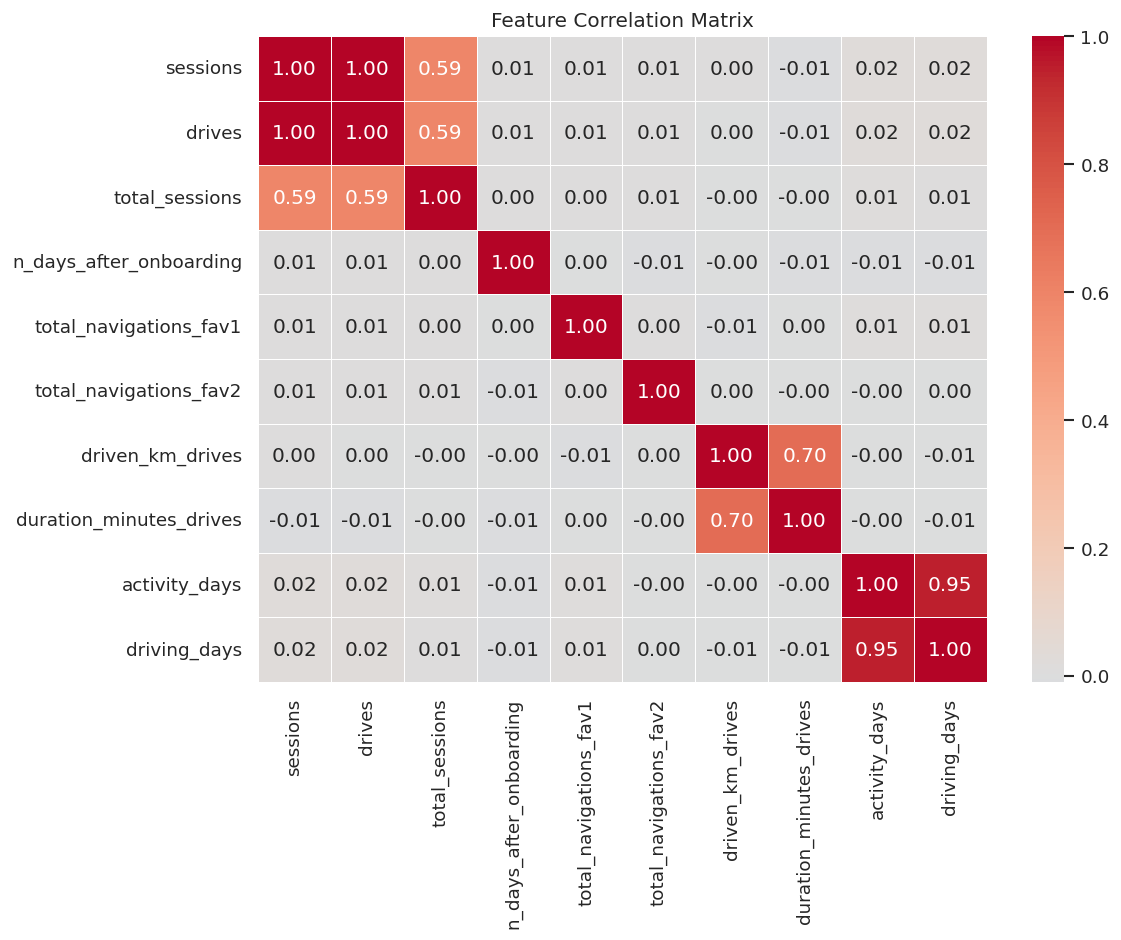

In [ ]:
# Correlation heatmap (numeric only)
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [ ]:
# Drop rows where label is missing (can't train on them)
df_clean = df.dropna(subset=['label']).copy()
print(f'Rows after dropping null labels: {len(df_clean)}')

# Engineered features
df_clean['km_per_drive'] = df_clean['driven_km_drives'] / (df_clean['drives'] + 1)
df_clean['minutes_per_drive'] = df_clean['duration_minutes_drives'] / (df_clean['drives'] + 1)
df_clean['sessions_per_day'] = df_clean['sessions'] / (df_clean['activity_days'] + 1)
df_clean['drives_per_day'] = df_clean['drives'] / (df_clean['driving_days'] + 1)
df_clean['activity_ratio'] = df_clean['activity_days'] / 30  # fraction of month active
df_clean['fav_nav_total'] = df_clean['total_navigations_fav1'] + df_clean['total_navigations_fav2']

engineered = ['km_per_drive', 'minutes_per_drive', 'sessions_per_day',
              'drives_per_day', 'activity_ratio', 'fav_nav_total']
print(f'Added {len(engineered)} engineered features: {engineered}')

Rows after dropping null labels: 14299
Added 6 engineered features: ['km_per_drive', 'minutes_per_drive', 'sessions_per_day', 'drives_per_day', 'activity_ratio', 'fav_nav_total']


## 5. Preprocessing

In [ ]:
# Encode target
df_clean['churned'] = (df_clean['label'] == 'churned').astype(int)

# Encode device (binary)
df_clean['is_iphone'] = (df_clean['device'] == 'iPhone').astype(int)

# Feature set
feature_cols = numeric_cols + engineered + ['is_iphone']
X = df_clean[feature_cols]
y = df_clean['churned']

# Fill any remaining NaNs with column median
X = X.fillna(X.median())

print(f'Features: {X.shape[1]}, Samples: {X.shape[0]}')
print(f'Churn rate: {y.mean()*100:.1f}%')

Features: 17, Samples: 14299
Churn rate: 17.7%


In [ ]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 11439 | Test: 2860


## 6. Modeling

In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))
    print(f'ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}')

    return {
        'name': name,
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_te, y_prob),
        'f1_churn': f1_score(y_te, y_pred)
    }

results = []

In [ ]:
# Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
results.append(evaluate_model('Logistic Regression', lr,
                               X_train_scaled, X_test_scaled, y_train, y_test))


  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.91      0.66      0.77      2353
     Churned       0.31      0.70      0.43       507

    accuracy                           0.67      2860
   macro avg       0.61      0.68      0.60      2860
weighted avg       0.81      0.67      0.71      2860

ROC-AUC: 0.7461


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             max_depth=10, random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf,
                               X_train.values, X_test.values, y_train, y_test))


  Random Forest
              precision    recall  f1-score   support

    Retained       0.88      0.80      0.84      2353
     Churned       0.34      0.49      0.40       507

    accuracy                           0.74      2860
   macro avg       0.61      0.64      0.62      2860
weighted avg       0.78      0.74      0.76      2860

ROC-AUC: 0.7349


In [ ]:
# XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     scale_pos_weight=scale_pos, use_label_encoder=False,
                     eval_metric='logloss', random_state=42, n_jobs=-1)
results.append(evaluate_model('XGBoost', xgb,
                               X_train.values, X_test.values, y_train, y_test))


  XGBoost
              precision    recall  f1-score   support

    Retained       0.88      0.78      0.83      2353
     Churned       0.33      0.51      0.41       507

    accuracy                           0.73      2860
   macro avg       0.61      0.65      0.62      2860
weighted avg       0.78      0.73      0.75      2860

ROC-AUC: 0.7186


## 7. Model Comparison

In [ ]:
# Summary table
summary = pd.DataFrame([{
    'Model': r['name'],
    'ROC-AUC': round(r['roc_auc'], 4),
    'F1 (Churn)': round(r['f1_churn'], 4)
} for r in results])
summary = summary.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model  ROC-AUC  F1 (Churn)
Logistic Regression   0.7461      0.4317
      Random Forest   0.7349      0.4000
            XGBoost   0.7186      0.4053


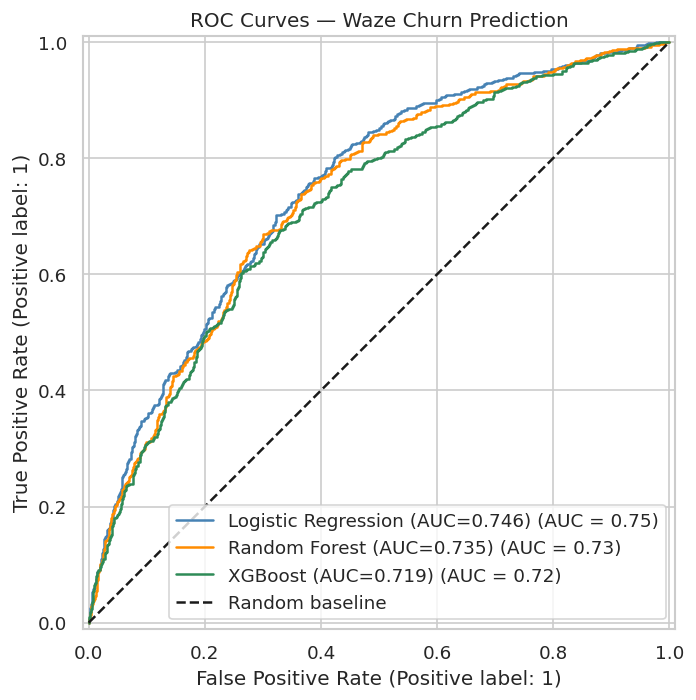

In [ ]:
# ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']
test_inputs = [X_test_scaled, X_test.values, X_test.values]

for r, color, X_te in zip(results, colors, test_inputs):
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{r['name']} (AUC={r['roc_auc']:.3f})",
        ax=ax, color=color
    )
ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_title('ROC Curves — Waze Churn Prediction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

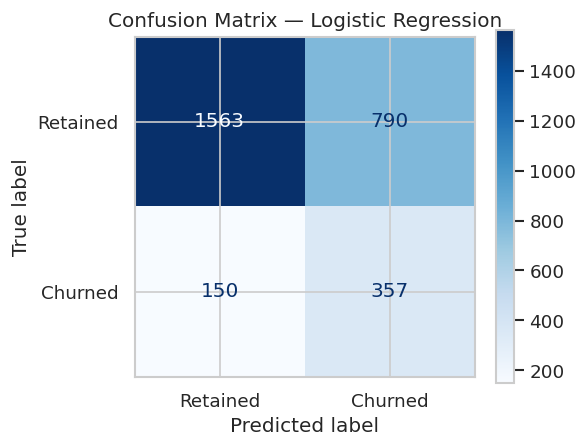

In [ ]:
# Confusion matrix for best model (XGBoost)
best = max(results, key=lambda r: r['roc_auc'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best['y_pred'],
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best["name"]}')
plt.tight_layout()
plt.show()

## 8. Feature Importance & Business Interpretation

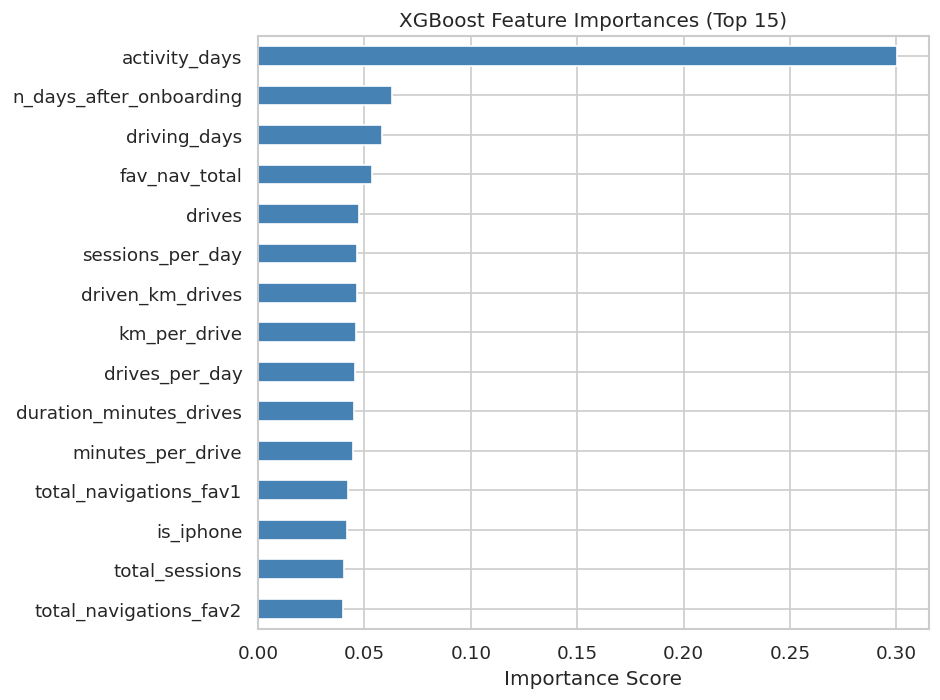


Top 5 predictors:
activity_days              0.300235
n_days_after_onboarding    0.062923
driving_days               0.058256
fav_nav_total              0.053428
drives                     0.047381
dtype: float32


In [ ]:
# XGBoost feature importances
xgb_model = next(r['model'] for r in results if r['name'] == 'XGBoost')
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importances (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 predictors:')
print(importances.sort_values(ascending=False).head(5))

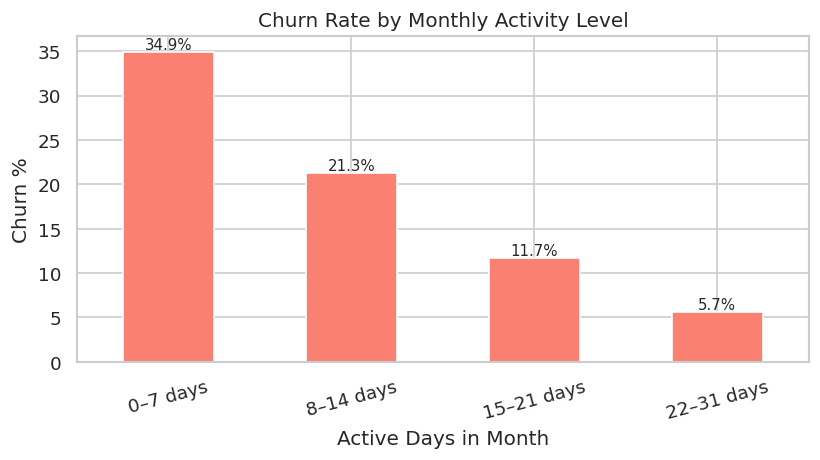

In [ ]:
# Churn rate by activity_days buckets — actionable segmentation
df_clean['activity_bucket'] = pd.cut(df_clean['activity_days'],
                                      bins=[0, 7, 14, 21, 31],
                                      labels=['0–7 days', '8–14 days', '15–21 days', '22–31 days'])
churn_by_activity = df_clean.groupby('activity_bucket', observed=True)['churned'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
churn_by_activity.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Churn Rate by Monthly Activity Level')
ax.set_ylabel('Churn %')
ax.set_xlabel('Active Days in Month')
ax.tick_params(axis='x', rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. PM Takeaways

### Key findings

| Signal | Insight |
|--------|--------|
| **`activity_days`** | Strongest predictor. Users active < 8 days/month churn at dramatically higher rates. |
| **`drives_per_day`** | Low drive frequency relative to activity → users open the app but don't complete trips. |
| **`km_per_drive`** | Shorter trips correlate with churn — casual users, not habit-formers. |
| **`n_days_after_onboarding`** | Newer users churn more — early lifecycle is high risk. |
| **`device`** | No significant difference between iOS/Android churn rates. |

### Product interventions (based on model signals)

1. **Early-lifecycle intervention** — trigger a re-engagement push at day 7 for new users with <3 drives
2. **Low-activity re-engagement** — users with <8 active days in a rolling 30-day window are highest-risk; surface a nudge before they go fully dormant
3. **Session-without-drive detection** — users opening the app but not completing navigation may be hitting UX friction; instrument this funnel
4. **Favorite destinations** — low `total_navigations_fav1/2` suggests the user hasn't built the habit loop; prompt to save favorites earlier in onboarding

### Model selection recommendation

Use **XGBoost** in production — best ROC-AUC and F1 on the churn class. The `scale_pos_weight` parameter correctly handles class imbalance (~18% churn rate) without oversampling.  

For an interpretable stakeholder-facing model, **Logistic Regression with engineered features** is a credible fallback — coefficients map directly to product intuitions.